In [36]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import pickle as pkl


# Path to your CSV folder (adjust this to where your files are stored)
csv_folder = "data/mnist-in-csv"
n_train = 100
n_cf = 2

connected_paths = False
path_type = 'pca'  # 'raw' or 'pca'
path_length = 'direct'  # 'direct' or 'local'


In [37]:

def plot_paths(images, labels, indices):
    
    # 4. Plot them
    plt.figure(figsize=(10, 10))
    for i, idx in enumerate(indices):
        plt.subplot(5, 5, i + 1)
        x = images[idx].reshape(28, 28)  # reshape to 28x28
        plt.imshow(x, cmap="gray")  # grayscale for MNIST
        plt.title(f"Index {idx}")

        plt.xticks([])   # remove tick labels, keep axis
        plt.yticks([])
        plt.xlabel(f"Label: {labels[idx]}")

    plt.tight_layout()
    plt.show()



def stratified_subsample(X, y, n_samples, random_state=42):
    X_sub, _, y_sub, _ = train_test_split(
        X, y,
        train_size=n_samples,
        stratify=y,
        random_state=random_state
    )
    return X_sub, y_sub


def load_mnist_data(csv_path, n_samples=None):
    # Load MNIST from CSV (assuming first column is label, rest are pixels)
    df = pd.read_csv(csv_path, dtype=np.uint8)
    X = df.iloc[:, 1:]/255
    X = X.astype("float32")

    # X = df.iloc[:, 1:].values.astype(np.float32)
    
    y = df.iloc[:, 0].values  

    # Subsample if n_samples is specified
    if n_samples is not None:
        if n_samples > X.shape[0]:
            raise ValueError(f"n_samples {n_samples} exceeds dataset size {X.shape[0]}")

        X, y = stratified_subsample(X, y, n_samples)
    
    return X, y



Load test and train full datasets

In [38]:

# List all CSV files in the folder
csv_files = [f for f in os.listdir(csv_folder) if f.endswith(".csv")]

# Read all CSVs into a dictionary of DataFrames
dataframes = {file: pd.read_csv(os.path.join(csv_folder, file)) for file in csv_files}

# Example: show basic info for each file
for name, df in dataframes.items():
    print(f"\n--- {name} ---")
    print(df.head())      # first 5 rows
    print(df.info())      # column details



--- mnist_train.csv ---
   label  1x1  1x2  1x3  1x4  1x5  1x6  1x7  1x8  1x9  ...  28x19  28x20  \
0      5    0    0    0    0    0    0    0    0    0  ...      0      0   
1      0    0    0    0    0    0    0    0    0    0  ...      0      0   
2      4    0    0    0    0    0    0    0    0    0  ...      0      0   
3      1    0    0    0    0    0    0    0    0    0  ...      0      0   
4      9    0    0    0    0    0    0    0    0    0  ...      0      0   

   28x21  28x22  28x23  28x24  28x25  28x26  28x27  28x28  
0      0      0      0      0      0      0      0      0  
1      0      0      0      0      0      0      0      0  
2      0      0      0      0      0      0      0      0  
3      0      0      0      0      0      0      0      0  
4      0      0      0      0      0      0      0      0  

[5 rows x 785 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to 28x28
dtypes: int64(785)
me

In [39]:
number_of_samples = 10000
X,y = load_mnist_data("data/mnist-in-csv/mnist_train.csv",
                           n_samples=number_of_samples)

X_train, X_dev, y_train, y_dev = train_test_split(X, y, test_size=0.2, random_state=42,shuffle=False)

X_test = dataframes['mnist_test.csv'].drop(columns=["label"])  # everything except the target
y_test = dataframes['mnist_test.csv']["label"]  # everything except the

In [56]:
print(X.head())
print(type(X))
# print(X.loc[6252])
print(X_train.head())
print(type(X_train))
print(X_train.loc[6252])

       1x1  1x2  1x3  1x4  1x5  1x6  1x7  1x8  1x9  1x10  ...  28x19  28x20  \
25171  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   0.0  ...    0.0    0.0   
25726  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   0.0  ...    0.0    0.0   
14385  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   0.0  ...    0.0    0.0   
50759  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   0.0  ...    0.0    0.0   
35230  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   0.0  ...    0.0    0.0   

       28x21  28x22  28x23  28x24  28x25  28x26  28x27  28x28  
25171    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0  
25726    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0  
14385    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0  
50759    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0  
35230    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0  

[5 rows x 784 columns]
<class 'pandas.core.frame.DataFrame'>
       1x1  1x2  1x3  1x4  1x5  1x6  1x7  1x8  1x9  1x10  ...  28x19  28x20  \


KeyError: 6252

In [41]:
y_train_df = pd.DataFrame(index=X_train.index)
y_train_df['y'] = y_train


In [42]:

raw_paths  = pd.read_csv("data/paths/mnist_paths_space-raw_k-20_paths-100000_datasize-10000.csv")
pca_paths  = pd.read_csv("data/paths/mnist_paths_space-pca_k-20_paths-100000_datasize-10000.csv")
face_paths = pd.read_csv("data/paths/mnist_paths_FACE_paths-539999_datasize-10000.csv")
face_paths['path_id'] = face_paths['path_id'].str.replace('_to', '', regex=False)

In [43]:
face_paths.head()

,index,next_index,path_id,start_label,end_label
0,3582,9768,3582_508,5,0
1,9768,566,3582_508,5,0
2,566,508,3582_508,5,0
3,1346,6566,1346_6122,5,4
4,6566,1964,1346_6122,5,4


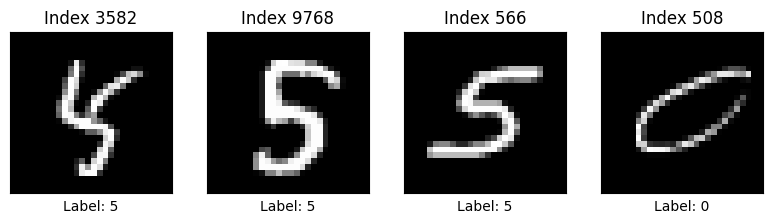

In [44]:
face_subset = face_paths.iloc[0:3]
plot_paths(np.array(X),list(y),list(face_subset['index'])+[508])

In [45]:
pca_paths.head()

,index,next_index,path_id,start_label,end_label
0,2456,9296,2456_5763,0,7
1,9296,3943,2456_5763,0,7
2,3943,5587,2456_5763,0,7
3,5587,9343,2456_5763,0,7
4,9343,1198,2456_5763,0,7


In [46]:
# for df in [raw_paths, pca_paths]:
#     df['index']+=1
#     df['next_index']+=1
#     df['path_id'] = df['path_id'].apply(increment_ids)


In [47]:
face_paths.head()

,index,next_index,path_id,start_label,end_label
0,3582,9768,3582_508,5,0
1,9768,566,3582_508,5,0
2,566,508,3582_508,5,0
3,1346,6566,1346_6122,5,4
4,6566,1964,1346_6122,5,4


In [48]:
pca_demo_path = pca_paths.iloc[0:8]
raw_demo_path = raw_paths.iloc[0:4]
face_demo_path = face_paths.iloc[0:3]

PCA DEMO


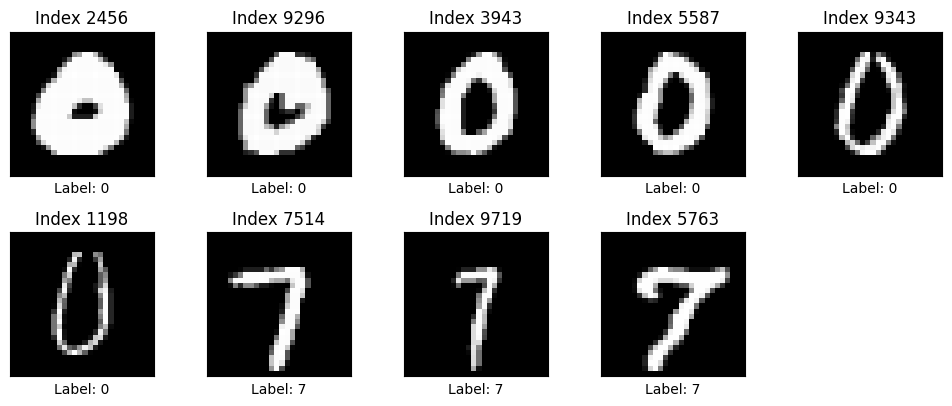

In [49]:

indices = list(pca_demo_path['index'])
final_ind = list([pca_demo_path['next_index'].iloc[-1]])

print("PCA DEMO")
plot_paths(np.array(X),list(y),indices+final_ind)


Raw demo path


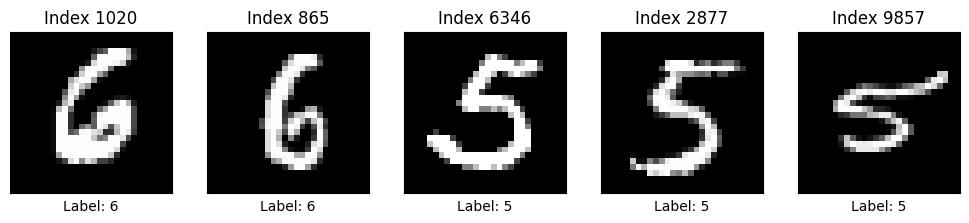

In [50]:

indices = list(raw_demo_path['index'])
final_ind = list([raw_demo_path['next_index'].iloc[-1]])
print("Raw demo path")
plot_paths(np.array(X),list(y),indices+final_ind)

FACE Demo Path


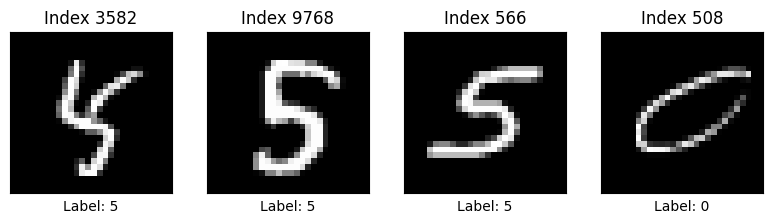

In [51]:

indices = list(face_demo_path['index'])
final_ind = list([face_demo_path['next_index'].iloc[-1]])
print("FACE Demo Path")
plot_paths(np.array(X),list(y),indices+final_ind)

In [52]:
def get_direct_paths(paths):
    direct_paths = pd.DataFrame()
    
    # Split path_id into start_id and end_id
    
    direct_paths[['index', 'next_index']] = paths['path_id'].str.split('_', expand=True).astype(int)
    direct_paths = direct_paths.drop_duplicates()
    return direct_paths

def get_local_paths(paths,y):
    return  paths[(y[paths['index']] != y[paths['next_index']])]
    

In [53]:
paths = {
    'raw':{'original':raw_paths},
    'pca':{'original':pca_paths},
    'face':{'original':face_paths}
}

for path_type, path in paths.items():
    
    direct_paths = get_direct_paths(path['original'])
    mask = direct_paths['index'].isin(X_train.index) & direct_paths['next_index'].isin(X_train.index)
    paths[path_type]['direct'] = {'inputs': direct_paths[mask]}
    print(f"{path_type} paths, Direct: {len(paths[path_type]['direct']['inputs'])}")

    local_paths = get_local_paths(path['original'],y)
    mask = local_paths['index'].isin(X_train.index) & local_paths['next_index'].isin(X_train.index)
    paths[path_type]['local'] = {'inputs':local_paths[mask]}
    print(f"{path_type} paths, Local: {len(paths[path_type]['local']['inputs'])}")

raw paths, Direct: 1756
raw paths, Local: 3468
pca paths, Direct: 1801
pca paths, Local: 2794


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x106ee25c0>>
Traceback (most recent call last):
  File "/Users/jonathanerskine/University of Bristol/gradient_supervision/counterfactual-gradient-alignment/cfa_venv/lib/python3.10/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


face paths, Direct: 1471
face paths, Local: 12063


In [ ]:

def sampler(g):
    # Sample exactly m rows from the group
    sampled = g.sample(n=n_cf, random_state=42)
    next_index_list = sampled["next_index"].tolist()
    y_list = y[next_index_list].tolist()  # grab corresponding y values
    return pd.Series({
        "next_index_list": next_index_list,
        "y_list": y_list
    })


In [ ]:
for path_type, path in paths.items():
    for path_length in ['direct','local']:
        paths[path_type][path_length]['outputs'] = (
                paths[path_type][path_length]['inputs'].groupby("index")
                    .filter(lambda g: len(g) >= n_cf)
                    .groupby("index")
                    .apply(sampler)
                    .reset_index()
                )
        print(f"{path_type} | {path_length} : {len(paths[path_type][path_length]['outputs'])}")
        

raw | direct : 494
raw | local : 298


/var/folders/_v/y6tzlp694c59fn1z7bdq1x240000gn/T/ipykernel_61776/316449026.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(sampler)
/var/folders/_v/y6tzlp694c59fn1z7bdq1x240000gn/T/ipykernel_61776/316449026.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(sampler)
/var/folders/_v/y6tzlp694c59fn1z7bdq1x240000gn/T/ipykernel_61776/316449026.py:7: DeprecationWarning: DataFrameGroupBy.apply 

pca | direct : 519
pca | local : 236
face | direct : 460
face | local : 207


/var/folders/_v/y6tzlp694c59fn1z7bdq1x240000gn/T/ipykernel_61776/316449026.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(sampler)
/var/folders/_v/y6tzlp694c59fn1z7bdq1x240000gn/T/ipykernel_61776/316449026.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(sampler)
/var/folders/_v/y6tzlp694c59fn1z7bdq1x240000gn/T/ipykernel_61776/316449026.py:7: DeprecationWarning: DataFrameGroupBy.apply 

In [ ]:


def compile_mnist(X,y,cf_X,cf_y):

    magnitude = np.ones(len(cf_X))
    magnitude = np.expand_dims(magnitude, axis=1)
    
    print(f'Returning {len(X)} samples with {len(cf_y)} counterfactuals')
    
    return {'X':np.array(X),
            'Y':list(y),
            'K':{
                'vector':cf_X,
                 'label':cf_y,
                 'magnitude':np.expand_dims(magnitude,axis=1), 
                 }}


In [ ]:
print(paths['face']['direct']['outputs'])

     index next_index_list  y_list
0       12    [4206, 7996]  [6, 5]
1       43    [9204, 8901]  [1, 9]
2       53    [6634, 7406]  [9, 0]
3      104    [4206, 6288]  [6, 2]
4      126     [5459, 244]  [5, 9]
..     ...             ...     ...
455   9839    [7996, 4206]  [5, 6]
456   9901    [7996, 4206]  [5, 6]
457   9930    [4206, 7996]  [6, 5]
458   9942    [1983, 6288]  [9, 2]
459   9977    [9382, 8667]  [8, 0]

[460 rows x 3 columns]


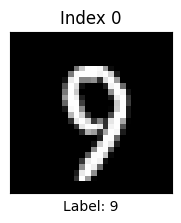

In [ ]:
plot_paths(np.array([X_train.loc[6634]]),list([y_train_df['y'].loc[6634]]),[0])

In [ ]:
for path_type, path in paths.items():
    for path_length in ['direct','local']:
        dataset = paths[path_type][path_length]['outputs']
        assert len(dataset) > n_train, "Data is too small, try reducing n_cf or incrasing X_train"
        dataset = dataset.sample(n=n_train, random_state=42)

        X_train_sample = np.array(X_train.loc[dataset['index']])
        y_train_sample = np.array(y_train_df['y'].loc[dataset['index']]).squeeze()
        
        cf_X_sample = np.array([X_train.loc[i] for i in dataset['next_index_list']])
        cf_y_sample = np.array([y_train_df['y'].loc[i] for i in dataset['next_index_list']])
        

        # Stripping html from unprocessed text, just to clean it up
        print('\ntrain_Data')
        cf_train={'original': compile_mnist(X_train_sample,y_train_sample,cf_X_sample,cf_y_sample)} # X,y,text,cf_X,cf_text

        print('\ndev_Data')
        cf_dev={'original': compile_mnist(X_dev,y_dev,
                                        np.expand_dims(np.zeros_like(X_dev),axis=1),
                                        np.expand_dims(np.zeros_like(y_dev),axis=1)
                                        )} # X,y,text,cf_X,cf_text

        print('\ntest_Data')
        cf_test={'original': compile_mnist(X_test,y_test,
                                        np.expand_dims(np.zeros_like(X_test),axis=1),
                                        np.expand_dims(np.zeros_like(y_test),axis=1)
                                        )} # X,y,text,cf_X,cf_text
        print('\ncontrol_Data')

        
        cf_X_control = cf_X_sample.reshape(cf_X_sample.shape[0]*cf_X_sample.shape[1],cf_X_sample.shape[2])
        cf_y_control = cf_y_sample.reshape(cf_y_sample.shape[0]*cf_y_sample.shape[1]) 
        X_control = np.vstack((X_train_sample, cf_X_control))
        y_control = np.hstack((y_train_sample, cf_y_control))
        
        cf_control={'original': compile_mnist(X_control,y_control,
                                        np.expand_dims(np.zeros_like(X_control),axis=1),
                                        np.expand_dims(np.zeros_like(y_control),axis=1)
                                        )} # X,y,text,cf_X,cf_text
        
        """
        ########################################################################################################################
        Save embeddings
        ########################################################################################################################
        """

        pickle_data = {'train':cf_train,'test':cf_test,'dev':cf_dev, 'control':cf_control,'n_classes': 10}

        embedding_path = f'data/integer_len{n_train}__connected_{str(connected_paths)}__path_{path_type}__length_{path_length}__cfn_{n_cf}.pkl'
        print(f"Saving to {embedding_path}")
        with open(embedding_path, 'wb') as file:
            pkl.dump(pickle_data, file)


train_Data
Returning 100 samples with 100 counterfactuals

dev_Data
Returning 2000 samples with 2000 counterfactuals

test_Data
Returning 10000 samples with 10000 counterfactuals

control_Data
Returning 300 samples with 300 counterfactuals
Saving to data/integer_len100__connected_False__path_raw__length_direct__cfn_2.pkl

train_Data
Returning 100 samples with 100 counterfactuals

dev_Data
Returning 2000 samples with 2000 counterfactuals

test_Data
Returning 10000 samples with 10000 counterfactuals

control_Data
Returning 300 samples with 300 counterfactuals
Saving to data/integer_len100__connected_False__path_raw__length_local__cfn_2.pkl

train_Data
Returning 100 samples with 100 counterfactuals

dev_Data
Returning 2000 samples with 2000 counterfactuals

test_Data
Returning 10000 samples with 10000 counterfactuals

control_Data
Returning 300 samples with 300 counterfactuals
Saving to data/integer_len100__connected_False__path_pca__length_direct__cfn_2.pkl

train_Data
Returning 100 sam

In [ ]:
len(y_train_sample)

100

In [ ]:
y_train_sample

array([1, 9, 6, 7, 7, 0, 0, 4, 1, 0, 4, 2, 9, 6, 9, 9, 1, 2, 7, 4, 8, 5,
       4, 3, 3, 5, 3, 4, 4, 2, 6, 4, 6, 1, 4, 7, 9, 2, 0, 9, 2, 3, 0, 9,
       3, 0, 8, 3, 6, 2, 9, 6, 5, 9, 2, 4, 2, 1, 5, 4, 5, 3, 1, 4, 3, 8,
       4, 6, 0, 1, 7, 0, 2, 3, 4, 8, 3, 9, 1, 5, 3, 5, 3, 8, 2, 2, 5, 6,
       2, 5, 5, 3, 0, 5, 9, 1, 9, 4, 6, 2], dtype=uint8)

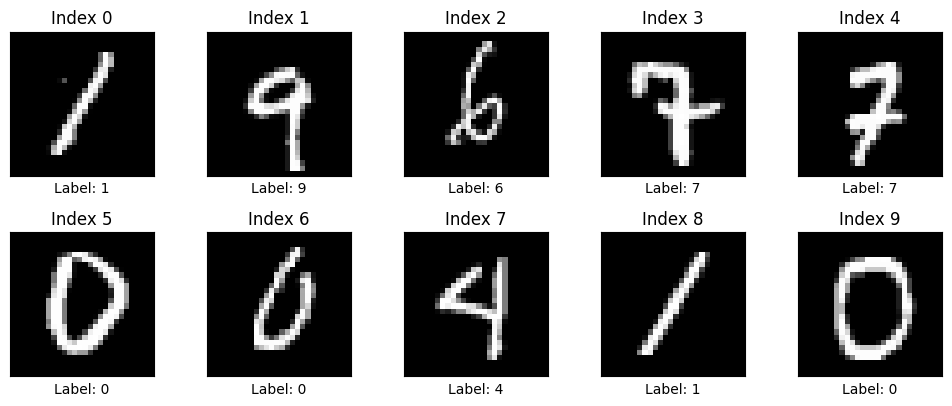

In [ ]:
plot_paths(X_train_sample,y_train_sample,[0,1,2,3,4,5,6,7,8,9])

In [ ]:
np.max(pickle_data['train']['original']['X'])

1.0

In [ ]:
len(pickle_data['train']['original']['Y'])


100